In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [25]:
class BMIstate(TypedDict):
    wt_kg: float 
    ht_m: float 
    bmi: float
    category: str

In [15]:
def calc_bmi(state: BMIstate)-> BMIstate:
    wt= state['wt_kg']
    ht= state['ht_m']

    bmi= wt/(ht**2)

    state['bmi']=round(bmi,2)

    return state

In [29]:
def label_bmi(state: BMIstate)-> BMIstate:
    bmi=state['bmi']
    if bmi< 18.3:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [30]:
graph=StateGraph(BMIstate)

#add nodes
graph.add_node('calc_BMI', calc_bmi)
graph.add_node('label_BMI', label_bmi)


#add edges
graph.add_edge( START, 'calc_BMI')
graph.add_edge('calc_BMI', 'label_BMI')
graph.add_edge('label_BMI', END)





#compile
workflow= graph.compile()




In [31]:
initial_state= {'wt_kg':88, 'ht_m':2}
final_state= workflow.invoke(initial_state)
print(final_state)

{'wt_kg': 88, 'ht_m': 2, 'bmi': 22.0, 'category': 'Normal'}


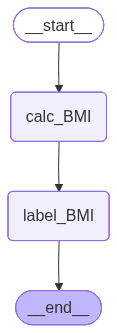

In [32]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())